## A Toy Version of the HHL Algorithm

In [1]:
# ============================================================
# Cell 1 : Imports and Initializations
# ============================================================

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator

from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_qsphere
)

from qiskit.circuit.library import UnitaryGate
from qiskit import transpile
from qiskit.circuit.library import RYGate, ZGate

import Our_Qiskit_Functions as oq

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import math as m

import warnings
warnings.filterwarnings('ignore')

# Simulators
state_sim = AerSimulator(method='statevector')
qasm_sim = AerSimulator()

HHL CONFIGURATION

--- General HHL assumptions ---
KAPPA_BOUND          : 1e+04
LAMBDA_BOUND_UPPER   : 100.0
LAMBDA_BOUND_LOWER   : 0.01

m_HHL                : 15
t0_HHL               : 0.028274
C_HHL                : 0.009000

--- Toy overrides ---
n                     : 1
m                     : 4
N                     : 2
M                     : 16
gamma                 : 2
t0                    : 0.785398
C                     : 0.45

Matrix A:
[[3. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


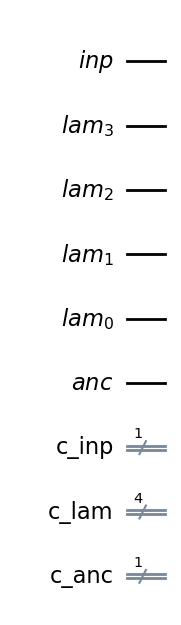


Initial Wavefunction:

1.0 |0>|0000>|0> 



In [2]:
# ============================================================
# Cell 2 : Problem Definition / Variable Initialization
# ============================================================

# ============================================================
# Spectral assumptions (general HHL)
# ============================================================

# Assumed upper bound on condition number:
#
#     kappa = |lambda_max|/|lambda_min|
#

KAPPA_BOUND = 1e4

# Assumed bounds on eigenvalues:
#
#     |lambda_j| <= LAMBDA_BOUND_UPPER
#     |lambda_j| >= LAMBDA_BOUND_LOWER
#

LAMBDA_BOUND_UPPER = 1e2
LAMBDA_BOUND_LOWER = 1e-2

# ============================================================
# Derived HHL parameters
# ============================================================

#
# We use:
#
#     U = exp(iAt)
#
# giving:
#
#     lambda*t = 2*pi*theta
#
# or:
#
#     theta = lambda*t/(2*pi)
#
# We interpret:
#
#     theta in (-1/2,1/2]
#
# so that both positive and negative
# eigenvalues are represented uniquely.
#
# To prevent phase aliasing:
#
#     |lambda_max|*t0 < pi
#
# To resolve the smallest eigenvalue:
#
#     |lambda_min|*t0/(2*pi)
#          >= 1/(2^m)
#
# Combining:
#
#     (2*kappa*pi)/(2^m |lambda_max|)
#          <= t0
#          < pi/|lambda_max|
#
# Therefore:
#
#     2^m >= 2*kappa
#

m_HHL = int(
    np.ceil(
        np.log2(
            2*KAPPA_BOUND
        )
    )
)

t0_HHL = (
    0.9*np.pi
    /
    LAMBDA_BOUND_UPPER
)

C_HHL = (
    0.9*
    LAMBDA_BOUND_LOWER
)

# ============================================================
# Toy overrides
# ============================================================

#
# Toy matrix:
#
# A = [[3,0],
#      [0,0.5]]
#
# Since:
#
# |lambda_max| < 4 = 2^2
#
# choose:
#
# t0 = pi/4
#
# Then:
#
# theta_1
#
# = 3(pi/4)/(2pi)
#
# = 3/8
#
# = 0.375
#
# = 0.0110_2
#
#
# theta_2
#
# = (0.5)(pi/4)/(2pi)
#
# = 1/16
#
# = 0.0625
#
# = 0.0001_2
#
# Therefore:
#
# m = 4
#
# gives exact QPE output without
# approximation leakage.
#

n = 1
m = 4

N = 2**n
M = 2**m

gamma = 2

t0 = np.pi/4

#
# Reciprocal rotation constant:
#
#     C <= |lambda_min|
#

C = 0.45

# ============================================================
# Registers
# ============================================================

anc = QuantumRegister(
    1,
    name='anc'
)

lam = QuantumRegister(
    m,
    name='lam'
)

inp = QuantumRegister(
    n,
    name='inp'
)

c_anc = ClassicalRegister(
    1,
    name='c_anc'
)

c_lam = ClassicalRegister(
    m,
    name='c_lam'
)

c_inp = ClassicalRegister(
    n,
    name='c_inp'
)

# ============================================================
# Main circuit
# ============================================================

qc = QuantumCircuit(
    anc,
    lam,
    inp,
    c_anc,
    c_lam,
    c_inp
)

# ============================================================
# Matrix A
# ============================================================

A = np.array([
    [3,0],
    [0,0.5]
], dtype=complex)

# ============================================================
# Placeholder observable
# ============================================================

Obs = np.eye(N)

# ============================================================
# Diagnostics
# ============================================================

print("================================================")
print("HHL CONFIGURATION")
print("================================================")

print("\n--- General HHL assumptions ---")

print(
f"KAPPA_BOUND          : {KAPPA_BOUND:.0e}"
)

print(
f"LAMBDA_BOUND_UPPER   : {LAMBDA_BOUND_UPPER}"
)

print(
f"LAMBDA_BOUND_LOWER   : {LAMBDA_BOUND_LOWER}"
)

print(
f"\nm_HHL                : {m_HHL}"
)

print(
f"t0_HHL               : {t0_HHL:.6f}"
)

print(
f"C_HHL                : {C_HHL:.6f}"
)

print("\n--- Toy overrides ---")

print(
f"n                     : {n}"
)

print(
f"m                     : {m}"
)

print(
f"N                     : {N}"
)

print(
f"M                     : {M}"
)

print(
f"gamma                 : {gamma}"
)

print(
f"t0                    : {t0:.6f}"
)

print(
f"C                     : {C}"
)

print("\nMatrix A:")
print(A)

display(
qc.draw(
    'mpl',
    reverse_bits=True
)
)

print("\nInitial Wavefunction:\n")

oq.Wavefunction(
qc,
systems=[n,m,1],
show_systems=[True,True,True],
precision=5,
column=True
)

In [3]:
# ============================================================
# Cell 3 : Input State Preparation
# ============================================================

def prepare_input_state(
    qc,
    inp,
    N,
    gamma,
    positions,
    m
):
    """
    Prepares input state |b>.
    """

    # --------------------------------------------------------
    # Infer number of qubits
    # --------------------------------------------------------

    n = len(inp)

    # --------------------------------------------------------
    # Validate N=2^n
    # --------------------------------------------------------

    n_check = int(np.log2(N))

    if 2**n_check != N:
        raise ValueError(
            "N must be a power of 2."
        )

    # --------------------------------------------------------
    # Remove duplicates while preserving order
    # --------------------------------------------------------

    positions = list(
        dict.fromkeys(
            positions
        )
    )

    # --------------------------------------------------------
    # Check empty support
    # --------------------------------------------------------

    if len(positions)==0:
        raise ValueError(
            "Support cannot be empty."
        )

    # --------------------------------------------------------
    # Validate support size
    # --------------------------------------------------------

    if len(positions)>gamma:

        raise ValueError(
            "Number of positions exceeds gamma."
        )

    # --------------------------------------------------------
    # Small toy preparation
    # --------------------------------------------------------

    if (N<=16) and (gamma<=4):

        b = np.zeros(
            N,
            dtype=complex
        )

        amp = (
            1/
            np.sqrt(
                len(positions)
            )
        )

        for p in positions:

            if (p<0) or (p>=N):

                raise ValueError(
                    f"Position {p} outside valid range."
                )

            b[p]=amp

        qc.initialize(
            b,
            inp
        )

        support_used = positions

        print("================================================")
        print("Exact sparse input state prepared")
        print("================================================")

    # --------------------------------------------------------
    # Large-scale fallback
    # --------------------------------------------------------

    else:

        print("================================================")
        print("Large-scale fallback mode activated")
        print("================================================")

        b = np.zeros(
            N,
            dtype=complex
        )

        fallback_support = min(
            4,
            N
        )

        amp = (
            1/
            np.sqrt(
                fallback_support
            )
        )

        for i in range(
            fallback_support
        ):
            b[i]=amp

        qc.initialize(
            b,
            inp
        )

        support_used = list(
            range(
                fallback_support
            )
        )

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    print("\nPrepared input state |b>:\n")

    oq.Wavefunction(
        qc,
        systems=[n,m,1],
        show_systems=[True,True,True],
        precision=5,
        column=True
    )

    print("\nDisplayed ordering:")
    print(
        "| inp_(n-1)...inp_0 | "
        "lam_(m-1)...lam_0 | "
        "anc |"
    )

    print("\nSelected support positions:")

    for p in support_used:

        print(
            f"{p:>2} --> |"
            f"{format(p,f'0{n_check}b')}>"
        )

    print("\n================================================")


Example Usage:

Exact sparse input state prepared

Prepared input state |b>:

0.70711 |0>|0000>|0> 
0.70711 |1>|0000>|0> 


Displayed ordering:
| inp_(n-1)...inp_0 | lam_(m-1)...lam_0 | anc |

Selected support positions:
 0 --> |0>
 1 --> |1>



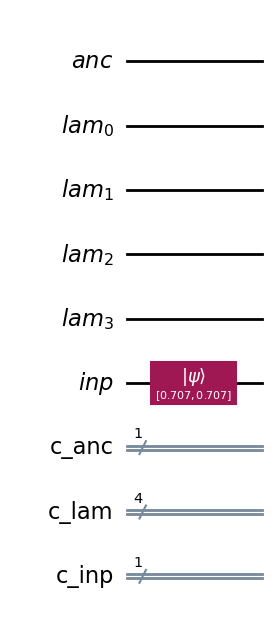

In [4]:
# ============================================================
# Example usage
# ============================================================

# Example:
#
# positions = [0,1]
#
# prepares:
#
# (|0> + |1>) / sqrt(2)
#

positions = [0,1]

print("\nExample Usage:\n")

prepare_input_state(
    qc,
    inp,
    N,
    gamma,
    positions,
    m
)

# ------------------------------------------------------------
# Visualize circuit
# ------------------------------------------------------------

display(
    qc.draw(
        'mpl'
    )
)

In [5]:
# ============================================================
# Cell 4 : Hamiltonian Simulation Unitary
# ============================================================

def hamiltonian_unitary(A, t0):
    """
    Constructs the Hamiltonian simulation unitary

        U = exp(+iAt0)

    using direct matrix exponentiation.

    ------------------------------------------------------------
    CONVENTION
    ------------------------------------------------------------

    We use:

        U = exp(+iAt0)

    so that QPE estimates:

        theta = lambda*t0/(2*pi)

    We interpret:

        theta in (-1/2,1/2]

    to allow both positive and negative eigenvalues.

    QPE itself outputs:

        theta mod 1

    so:

        theta < 0

    appears as:

        theta + 1

    ------------------------------------------------------------
    INPUTS
    ------------------------------------------------------------

    A : numpy array
        Hermitian system matrix

    t0 : float
        Base evolution time

    ------------------------------------------------------------
    RETURNS
    ------------------------------------------------------------

    U : numpy array

    U_gate : UnitaryGate
    """

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    rows, cols = A.shape

    if rows != cols:
        raise ValueError(
            "A must be square."
        )

    # --------------------------------------------------------
    # Hermiticity check
    # --------------------------------------------------------

    if not np.allclose(
        A,
        A.conj().T
    ):

        raise ValueError(
            "A must be Hermitian."
        )

    # --------------------------------------------------------
    # Compute:
    #
    # U = exp(+iAt0)
    # --------------------------------------------------------

    U = la.expm(
        1j*A*t0
    )

    # --------------------------------------------------------
    # Convert to gate
    # --------------------------------------------------------

    U_gate = UnitaryGate(
        U,
        label="U"
    )

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    print("================================================")
    print("Hamiltonian Simulation Unitary")
    print("================================================")

    print("\nMatrix A:\n")
    print(A)

    print("\nBase evolution time t0:\n")
    print(round(t0,6))

    print("\nUnitary U = exp(+iAt0):\n")
    print(
        np.round(
            U,
            5
        )
    )

    # --------------------------------------------------------
    # Eigenvalue diagnostics
    # --------------------------------------------------------

    eigvals, eigvecs = np.linalg.eigh(A)

    print("\nEigenvalues of A:\n")

    print(
        np.round(
            eigvals,
            5
        )
    )

    print(
        "\nCorresponding QPE phases:"
    )

    print(
        "\n(theta interpreted in (-1/2,1/2])\n"
    )

    for idx, lam_val in enumerate(eigvals):

        theta = (
            lam_val*t0
        )/(2*np.pi)

        theta_qpe = theta % 1

        print(
            f"lambda_{idx+1}"
            f" = {lam_val:.5f}"
        )

        print(
            f"      theta = {theta:.5f}"
        )

        print(
            f"      QPE output = {theta_qpe:.5f}"
        )

    print("\n================================================")

    return U, U_gate


# ============================================================
# Example usage
# ============================================================

U, U_gate = hamiltonian_unitary(
    A,
    t0
)

Hamiltonian Simulation Unitary

Matrix A:

[[3. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

Base evolution time t0:

0.785398

Unitary U = exp(+iAt0):

[[-0.70711+0.70711j  0.     +0.j     ]
 [ 0.     +0.j       0.92388+0.38268j]]

Eigenvalues of A:

[0.5 3. ]

Corresponding QPE phases:

(theta interpreted in (-1/2,1/2])

lambda_1 = 0.50000
      theta = 0.06250
      QPE output = 0.06250
lambda_2 = 3.00000
      theta = 0.37500
      QPE output = 0.37500



In [6]:
# ============================================================
# Cell 5 : Quantum Phase Estimation (QPE)
# ============================================================

def qpe(qc, lam, inp, U_gate, m):
    """
    Applies Quantum Phase Estimation (QPE).

    ------------------------------------------------------------
    INPUTS
    ------------------------------------------------------------

    qc : QuantumCircuit
        Main circuit

    lam : QuantumRegister
        Eigenvalue / phase register

    inp : QuantumRegister
        Input register containing eigenstate superposition

    U_gate : UnitaryGate
        Hamiltonian simulation unitary:

            U = exp(+iAt0)

    m : int
        Number of eigenvalue register qubits

    ------------------------------------------------------------
    CONVENTION
    ------------------------------------------------------------

    QPE estimates:

        theta = lambda*t0/(2*pi)

    with:

        theta in (-1/2,1/2]

    to allow both positive and negative eigenvalues.

    QPE itself returns:

        theta mod 1

    ------------------------------------------------------------
    PHASE REGISTER INTERPRETATION
    ------------------------------------------------------------

    The lam register stores an m-bit estimate of:

        2^m * theta

    equivalently:

        round(2^m * theta)

    If the measured bitstring represents
    integer y:

        y ≈ 2^m * theta

    then:

        theta ≈ y/(2^m)

    ------------------------------------------------------------
    IMPLEMENTATION
    ------------------------------------------------------------

    1. Apply Hadamards to lam register
    2. Apply controlled-U^(2^k)
    3. Apply inverse QFT

    ------------------------------------------------------------
    NOTE
    ------------------------------------------------------------

    We explicitly assign:

        U^(2^k)

    to:

        lam[(m-1-k)]

    so that displayed phase bitstrings appear as:

        |lam_(m-1)...lam_0>

    in standard MSB-left notation.

    Therefore:

        do_swaps=False

    because significance alignment has already
    been handled explicitly.

    Note: 
    We used Professor's version of QPE compatible with Qiskit ordering, not N&C textbook's version. 
    We used lam[(m-1-k)] as the control qubit for U_k gate (not lam[k]) 
    Also, we used do_swaps=False because the output is already in Qiskit ordering needing no swaps in Professor's version

    ------------------------------------------------------------
    PEDAGOGICAL GOAL
    ------------------------------------------------------------

    This implementation intentionally favors
    clarity over efficiency.
    """

    print("================================================")
    print("Applying Quantum Phase Estimation")
    print("================================================")

    n = len(inp)

    # --------------------------------------------------------
    # Step 1 : Hadamards on eigenvalue register
    # --------------------------------------------------------

    print("\nStep 1 : Applying Hadamards to lam register")

    for qubit in lam:

        qc.h(qubit)

    # --------------------------------------------------------
    # Step 2 : Controlled powers of U
    # --------------------------------------------------------

    print("\nStep 2 : Applying controlled powers of U")

    for k in range(m):

        power = 2**k

        print(
            f"Applying controlled-U^{power}"
        )

        # ----------------------------------------------------
        # Construct:
        #
        # U^(2^k)
        # ----------------------------------------------------

        U_power_matrix = np.linalg.matrix_power(
            U_gate.to_matrix(),
            power
        )

        U_power_gate = UnitaryGate(
            U_power_matrix,
            label=f"U^{power}"
        )

        # ----------------------------------------------------
        # Controlled version
        # ----------------------------------------------------

        controlled_U = (
            U_power_gate.control(1)
        )

        # ----------------------------------------------------
        # Apply:
        #
        # U^(2^k)
        #
        # controlled by:
        #
        # lam[(m-1-k)]
        # ----------------------------------------------------

        qc.append(
            controlled_U,
            [lam[(m-1-k)]]
            +
            list(inp)
        )

    # --------------------------------------------------------
    # Step 3 : Apply inverse QFT
    # --------------------------------------------------------

    print(
        "\nStep 3 : Applying inverse QFT"
    )

    iqft = QFT(
        num_qubits=m,
        inverse=True,
        do_swaps=False
    ).to_gate(
        label="IQFT"
    )

    qc.append(
        iqft,
        lam
    )

    print("\n================================================")
    print("QPE Complete")
    print("================================================")

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    print(
        "\nCircuit after QPE:\n"
    )

    print(
        qc.draw('text')
    )

    print(
        "\nWavefunction after QPE:\n"
    )

    qc_transpiled = transpile(
        qc,
        state_sim
    )

    oq.Wavefunction(
        qc_transpiled,
        systems=[n,m,1],
        show_systems=[True,True,True],
        precision=5,
        column=True
    )

    print(
        "\nDisplayed ordering:"
    )

    print(
        "| inp_(n-1)...inp_0 | "
        "lam_(m-1)...lam_0 | "
        "anc |"
    )

    # --------------------------------------------------------
    # Optional debugging
    # --------------------------------------------------------

    """
    print("\nFor Debugging")

    statevec = Statevector(qc)

    for i, amp in enumerate(statevec):

        if abs(amp)>1e-10:

            bitstring = format(
                i,
                f'0{qc.num_qubits}b'
            )

            print(
                f"{amp:.5f}   "
                f"inp = {bitstring[0:n]}   "
                f"lam = {bitstring[n:n+m]}   "
                f"anc = {bitstring[-1]}"
            )
    """

    print(
        "\n================================================"
    )


Applying Quantum Phase Estimation

Step 1 : Applying Hadamards to lam register

Step 2 : Applying controlled powers of U
Applying controlled-U^1
Applying controlled-U^2
Applying controlled-U^4
Applying controlled-U^8

Step 3 : Applying inverse QFT

QPE Complete

Circuit after QPE:

                                                                             
    anc: ────────────────────────────────────────────────────────────────────
                      ┌───┐                                         ┌───────┐
  lam_0: ─────────────┤ H ├─────────────────────────────────────■───┤0      ├
                      ├───┤                                     │   │       │
  lam_1: ─────────────┤ H ├──────────────────────────────■──────┼───┤1      ├
                      ├───┤                              │      │   │  IQFT │
  lam_2: ─────────────┤ H ├───────────────────────■──────┼──────┼───┤2      ├
                      ├───┤                       │      │      │   │       │
  lam_3: ──────

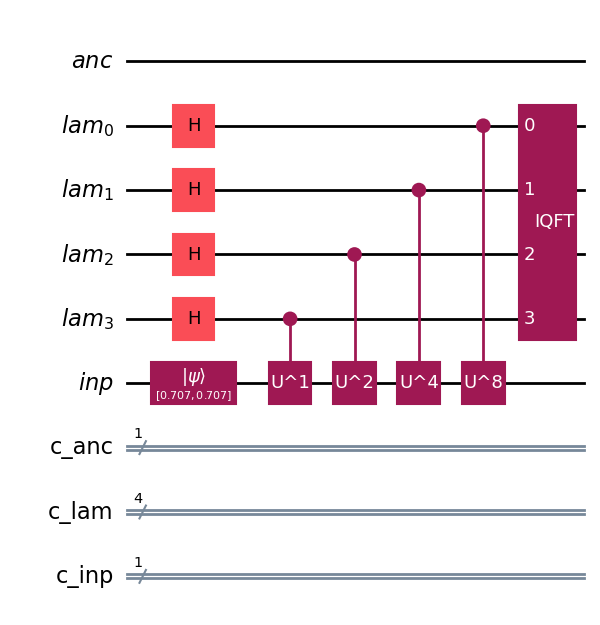

In [7]:
# ============================================================
# Example usage
# ============================================================

qpe(
    qc,
    lam,
    inp,
    U_gate,
    m
)

# ------------------------------------------------------------
# Visualize circuit
# ------------------------------------------------------------

display(
    qc.draw('mpl')
)

In [8]:
# ============================================================
# Cell 6 : Inverse Quantum Phase Estimation (QPE†)
# ============================================================

def qpe_dagger(qc, lam, inp, U_gate, m):
    """
    Applies the inverse of QPE.

    ------------------------------------------------------------
    PURPOSE
    ------------------------------------------------------------

    Reverses:

        |phase>|eigenstate>

    back into:

        |0...0>|eigenstate>

    using exactly the same conventions as qpe().

    ------------------------------------------------------------
    IMPLEMENTATION
    ------------------------------------------------------------

    Reverse order of QPE:

    1. Apply QFT
    2. Apply controlled-(U^(2^k))†
       in reverse order
    3. Apply Hadamards

    ------------------------------------------------------------
    NOTE
    ------------------------------------------------------------

    Uses same convention:

        U^(2^k)
        controlled by
        lam[(m-1-k)]

    with:

        do_swaps=False

    so that qpe_dagger() exactly inverts qpe().
    """

    print("================================================")
    print("Applying Inverse QPE")
    print("================================================")

    n = len(inp)

    # --------------------------------------------------------
    # Step 1 : Apply QFT
    # --------------------------------------------------------

    print("\nStep 1 : Applying QFT")

    qft = QFT(
        num_qubits=m,
        inverse=False,
        do_swaps=False
    ).to_gate(
        label="QFT"
    )

    qc.append(
        qft,
        lam
    )

    # --------------------------------------------------------
    # Step 2 : Controlled inverse powers
    # --------------------------------------------------------

    print(
        "\nStep 2 : Applying controlled inverse powers"
    )

    for k in reversed(range(m)):

        power = 2**k

        print(
            f"Applying controlled-(U^{power})†"
        )

        # ----------------------------------------------------
        # Construct:
        #
        # (U^(2^k))†
        # ----------------------------------------------------

        U_power_matrix = np.linalg.matrix_power(
            U_gate.to_matrix(),
            power
        )

        U_power_gate = UnitaryGate(
            U_power_matrix,
            label=f"U^{power}"
        )

        U_power_dagger = (
            U_power_gate.inverse()
        )

        controlled_U_dagger = (
            U_power_dagger.control(1)
        )

        # ----------------------------------------------------
        # Same control convention as qpe()
        # ----------------------------------------------------

        qc.append(
            controlled_U_dagger,
            [lam[(m-1-k)]]
            +
            list(inp)
        )

    # --------------------------------------------------------
    # Step 3 : Hadamards
    # --------------------------------------------------------

    print(
        "\nStep 3 : Applying Hadamards"
    )

    for qubit in lam:

        qc.h(qubit)

    print("\n================================================")
    print("Inverse QPE Complete")
    print("================================================")

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    print(
        "\nCircuit after QPE†:\n"
    )

    print(
        qc.draw('text')
    )

    print(
        "\nWavefunction after QPE†:\n"
    )

    qc_transpiled = transpile(
        qc,
        state_sim
    )

    oq.Wavefunction(
        qc_transpiled,
        systems=[n,m,1],
        show_systems=[True,True,True],
        precision=5,
        column=True
    )

    print(
        "\nDisplayed ordering:"
    )

    print(
        "| inp_(n-1)...inp_0 | "
        "lam_(m-1)...lam_0 | "
        "anc |"
    )

    print(
        "\n================================================"
    )

In [9]:
RUN_QPE_DAGGER_TEST = False

if RUN_QPE_DAGGER_TEST:

    # ============================================================
    # Example Usage : QPE followed by QPE†
    # Sanity Check
    # ============================================================
    
    print("\n================================================")
    print("SANITY CHECK : QPE followed by QPE†")
    print("================================================")
    
    qpe_dagger(
        qc,
        lam,
        inp,
        U_gate,
        m
    )
    
    # ------------------------------------------------------------
    # Visualize final circuit
    # ------------------------------------------------------------
    
    display(
        qc.draw('mpl')
    )
    
    # ------------------------------------------------------------
    # Final state verification
    # ------------------------------------------------------------
    
    print("\nExpected final state:\n")
    
    print(
    """
    lam should return to:
    
    |0000>
    
    while inp should return to:
    
    (|0> + |1>)/sqrt(2)
    
    Thus expected state:
    
    0.70711 |0>|0000>|0>
    0.70711 |1>|0000>|0>
    
    (or a state that is equivalent to this up to a global phase factor)
    """
    )
    
    print("\nFinal wavefunction:\n")
    
    qc_transpiled = transpile(
            qc,
            state_sim
        )
    
    oq.Wavefunction(
        qc_transpiled,
        systems=[n,m,1],
        show_systems=[True,True,True],
        precision=5,
        column=True
    )
    
    print("\nDisplayed ordering:")
    print("| inp_(n-1)...inp_0 | lam_(m-1)...lam_0 | anc |")
    
    print("\n================================================")

In [10]:
# ============================================================
# Cell 7 : Encode Eigenvalue Inverses
# ============================================================

def encode_inverses(
    qc,
    anc,
    lam,
    m,
    t0,
    C
):
    """
    Encodes reciprocal eigenvalues into ancilla amplitudes.

    ------------------------------------------------------------
    CONVENTION
    ------------------------------------------------------------

    QPE stores:

        y ≈ 2^m * theta

    where:

        theta in (-1/2,1/2]

    Decode:

                    y
        theta = ---------
                  2^m

    if:

        y < 2^(m-1)

    otherwise:

                     y
        theta = -------- - 1
                  2^m


    Recover eigenvalue estimate:

        lambda_est

        = 2*pi*theta/t0


    Ancilla encoding:

        sqrt(1-(C/lambda)^2)|0>

        +

        (C/lambda)|1>

    ------------------------------------------------------------
    INPUTS
    ------------------------------------------------------------

    qc : QuantumCircuit

    anc : ancilla register

    lam : eigenvalue register

    m : number of phase qubits

    t0 : evolution time

    C : reciprocal scaling constant
    """

    print("================================================")
    print("Encoding Eigenvalue Inverses")
    print("================================================")

    M = 2**m

    # --------------------------------------------------------
    # Loop over all phase-register values
    # --------------------------------------------------------

    for y in range(M):

        bitstring = format(
            y,
            f'0{m}b'
        )

        # ----------------------------------------------------
        # Decode signed phase
        # ----------------------------------------------------

        if y < M//2:

            theta = y/M

        else:

            theta = y/M - 1

        # ----------------------------------------------------
        # Skip zero eigenvalue
        # ----------------------------------------------------

        if abs(theta) < 1e-12:

            continue

        # ----------------------------------------------------
        # Recover eigenvalue estimate
        # ----------------------------------------------------

        lambda_est = (
            2*np.pi*theta
        )/t0

        # ----------------------------------------------------
        # Safety
        # ----------------------------------------------------

        if abs(lambda_est) < C:

            continue

        # ----------------------------------------------------
        # Rotation amplitude
        # ----------------------------------------------------

        amp = C/abs(lambda_est)

        amp = min(
            amp,
            1.0
        )

        # ----------------------------------------------------
        # HHL rotation:
        #
        # sin(theta_rot/2)
        #
        # = C/|lambda|
        # ----------------------------------------------------

        theta_rot = (
            2*np.arcsin(
                amp
            )
        )

        print(
            f"\ny = {y:2d}"
        )

        print(
            f"bitstring = {bitstring}"
        )

        print(
            f"theta = {theta:.5f}"
        )

        print(
            f"lambda_est = {lambda_est:.5f}"
        )

        print(
            f"C/lambda = {C/lambda_est:.5f}"
        )

        print(
            f"rotation angle = {theta_rot:.5f}"
        )

        # ----------------------------------------------------
        # Controlled RY
        # ----------------------------------------------------

        ry_gate = RYGate(
            theta_rot
        )

        controlled_ry = (
            ry_gate.control(
                m,
                ctrl_state=bitstring
            )
        )

        qc.append(
            controlled_ry,
            list(lam)
            +
            [anc[0]]
        )

        # ----------------------------------------------------
        # Negative eigenvalue:
        #
        # apply minus sign to |1>
        # ----------------------------------------------------

        if lambda_est < 0:

            z_gate = ZGate()

            controlled_z = (
                z_gate.control(
                    m,
                    ctrl_state=bitstring
                )
            )

            qc.append(
                controlled_z,
                list(lam)
                +
                [anc[0]]
            )

    print("\n================================================")
    print("Inverse Encoding Complete")
    print("================================================")

    print("\nCircuit:\n")

    print(
        qc.draw('text')
    )

    print("\n================================================")


EXAMPLE : Encoding Reciprocal Eigenvalues
Encoding Eigenvalue Inverses

y =  1
bitstring = 0001
theta = 0.06250
lambda_est = 0.50000
C/lambda = 0.90000
rotation angle = 2.23954

y =  2
bitstring = 0010
theta = 0.12500
lambda_est = 1.00000
C/lambda = 0.45000
rotation angle = 0.93353

y =  3
bitstring = 0011
theta = 0.18750
lambda_est = 1.50000
C/lambda = 0.30000
rotation angle = 0.60939

y =  4
bitstring = 0100
theta = 0.25000
lambda_est = 2.00000
C/lambda = 0.22500
rotation angle = 0.45389

y =  5
bitstring = 0101
theta = 0.31250
lambda_est = 2.50000
C/lambda = 0.18000
rotation angle = 0.36197

y =  6
bitstring = 0110
theta = 0.37500
lambda_est = 3.00000
C/lambda = 0.15000
rotation angle = 0.30114

y =  7
bitstring = 0111
theta = 0.43750
lambda_est = 3.50000
C/lambda = 0.12857
rotation angle = 0.25786

y =  8
bitstring = 1000
theta = -0.50000
lambda_est = -4.00000
C/lambda = -0.11250
rotation angle = 0.22548

y =  9
bitstring = 1001
theta = -0.43750
lambda_est = -3.50000
C/lambda = -0

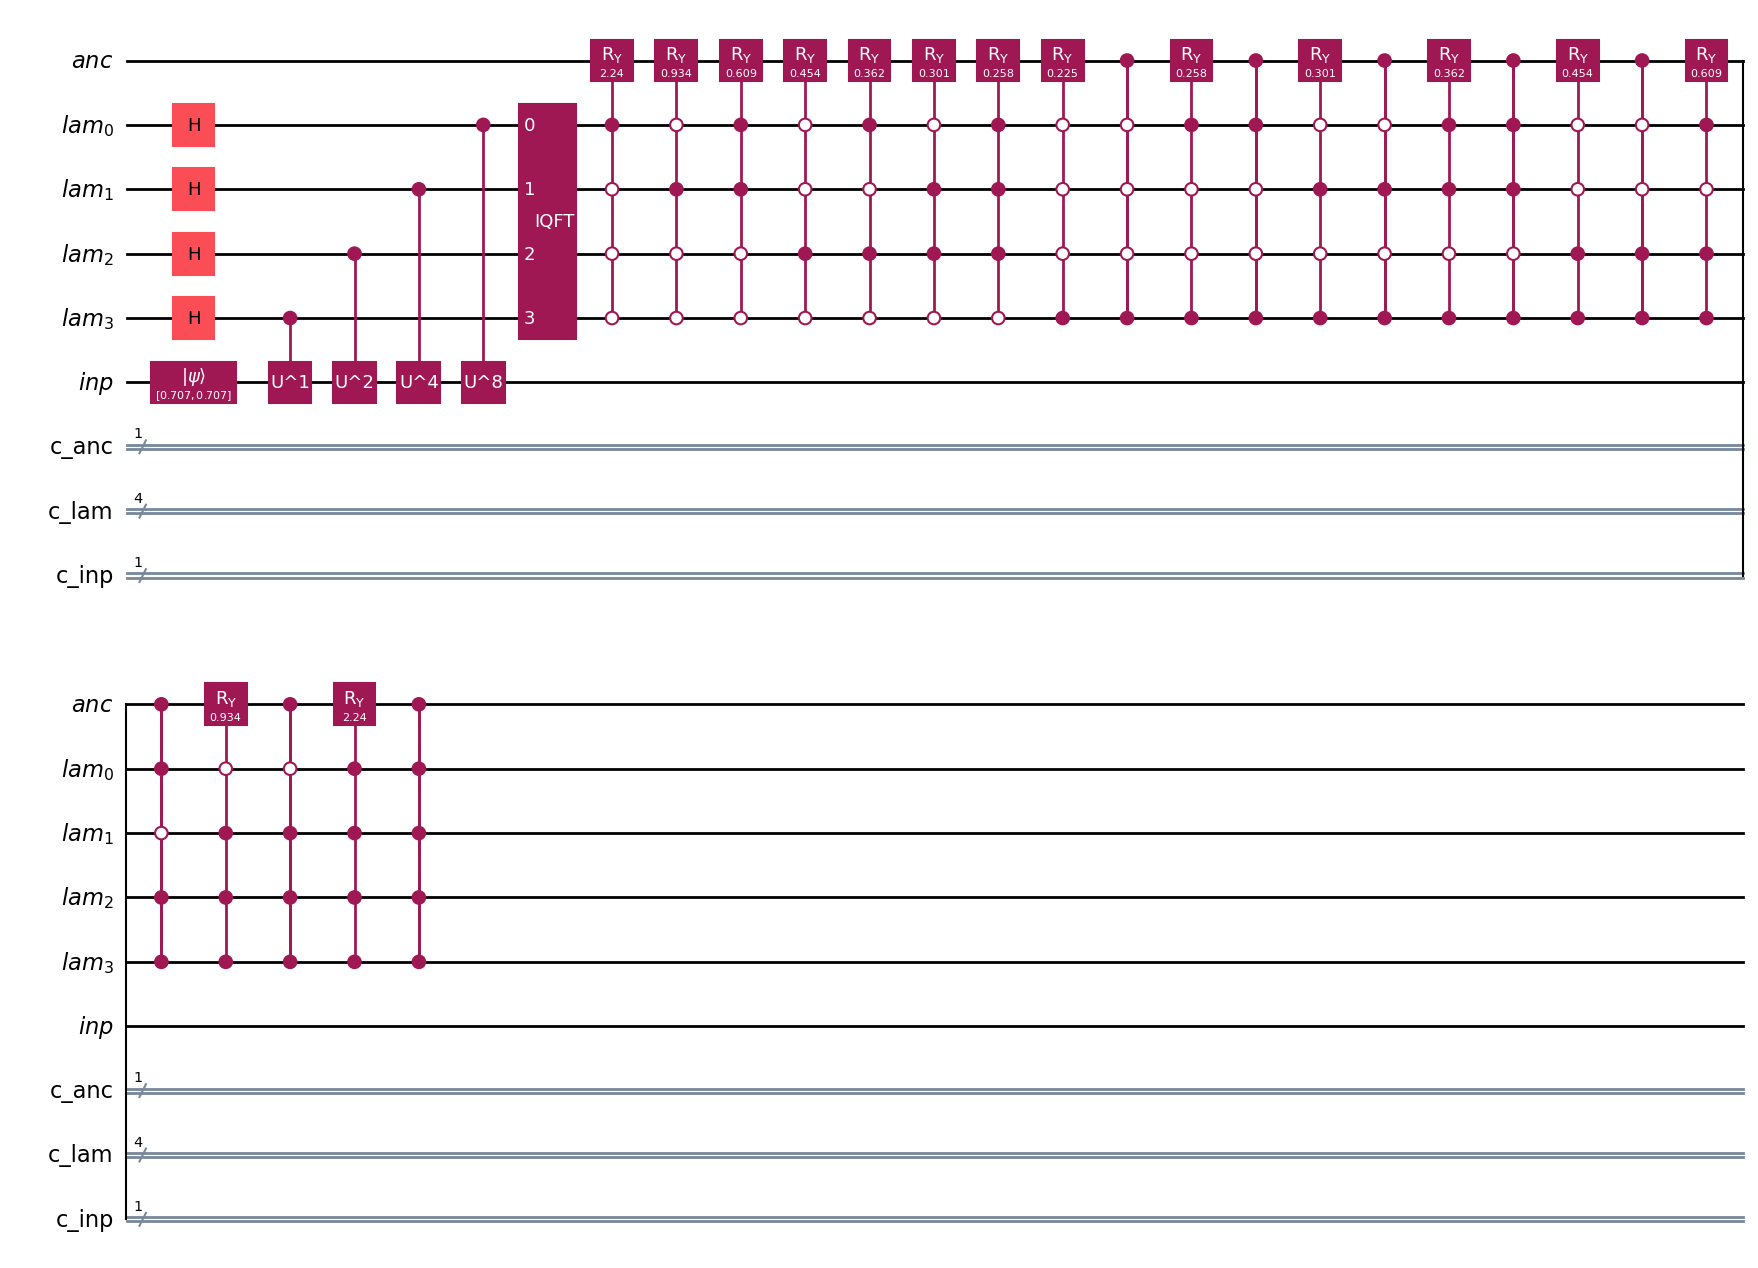


Wavefunction after inverse encoding:

-0.55173-0.42936j |0>|0110>|0> 
-0.08371-0.06514j |0>|0110>|1> 
-0.24324-0.18929j |1>|0001>|0> 
-0.50224-0.39084j |1>|0001>|1> 


Displayed ordering:
| inp_(n-1)...inp_0 | lam_(m-1)...lam_0 | anc |



In [11]:
# ============================================================
# Example Usage : Encode Eigenvalue Inverses
# ============================================================

RUN_INVERSE_ENCODING_TEST = True

if RUN_INVERSE_ENCODING_TEST:

    print("\n================================================")
    print("EXAMPLE : Encoding Reciprocal Eigenvalues")
    print("================================================")

    encode_inverses(
        qc,
        anc,
        lam,
        m,
        t0,
        C
    )

    # --------------------------------------------------------
    # Expected amplitudes
    # --------------------------------------------------------

    print("\nExpected ancilla amplitudes:\n")

    print(
    f"""
For:

lambda_1 = 3

C/lambda_1

= {C:.3f}/3

= {C/3:.5f}

Ancilla:

sqrt(1-(C/3)^2)|0>
+
(C/3)|1>


For:

lambda_2 = 0.5

C/lambda_2

= {C:.3f}/0.5

= {C/0.5:.5f}

Ancilla:

sqrt(1-(C/0.5)^2)|0>
+
(C/0.5)|1>

Smaller eigenvalues should therefore
have larger |1> amplitudes.
"""
    )

    # --------------------------------------------------------
    # Visualize circuit
    # --------------------------------------------------------

    display(
        qc.draw('mpl')
    )

    # --------------------------------------------------------
    # Final state
    # --------------------------------------------------------

    print("\nWavefunction after inverse encoding:\n")

    # Needed because Aer sometimes does not
    # directly simulate controlled-unitary

    qc_transpiled = transpile(
        qc,
        state_sim
    )

    oq.Wavefunction(
        qc_transpiled,
        systems=[n,m,1],
        show_systems=[True,True,True],
        precision=5,
        column=True
    )

    print("\nDisplayed ordering:")
    print(
        "| inp_(n-1)...inp_0 | "
        "lam_(m-1)...lam_0 | "
        "anc |"
    )

    print("\n================================================")


Applying QPE†
Applying Inverse QPE

Step 1 : Applying QFT

Step 2 : Applying controlled inverse powers
Applying controlled-(U^8)†
Applying controlled-(U^4)†
Applying controlled-(U^2)†
Applying controlled-(U^1)†

Step 3 : Applying Hadamards

Inverse QPE Complete

Circuit after QPE†:

                                                                             »
    anc: ────────────────────────────────────────────────────────────────────»
                      ┌───┐                                         ┌───────┐»
  lam_0: ─────────────┤ H ├─────────────────────────────────────■───┤0      ├»
                      ├───┤                                     │   │       │»
  lam_1: ─────────────┤ H ├──────────────────────────────■──────┼───┤1      ├»
                      ├───┤                              │      │   │  IQFT │»
  lam_2: ─────────────┤ H ├───────────────────────■──────┼──────┼───┤2      ├»
                      ├───┤                       │      │      │   │       │»
  la

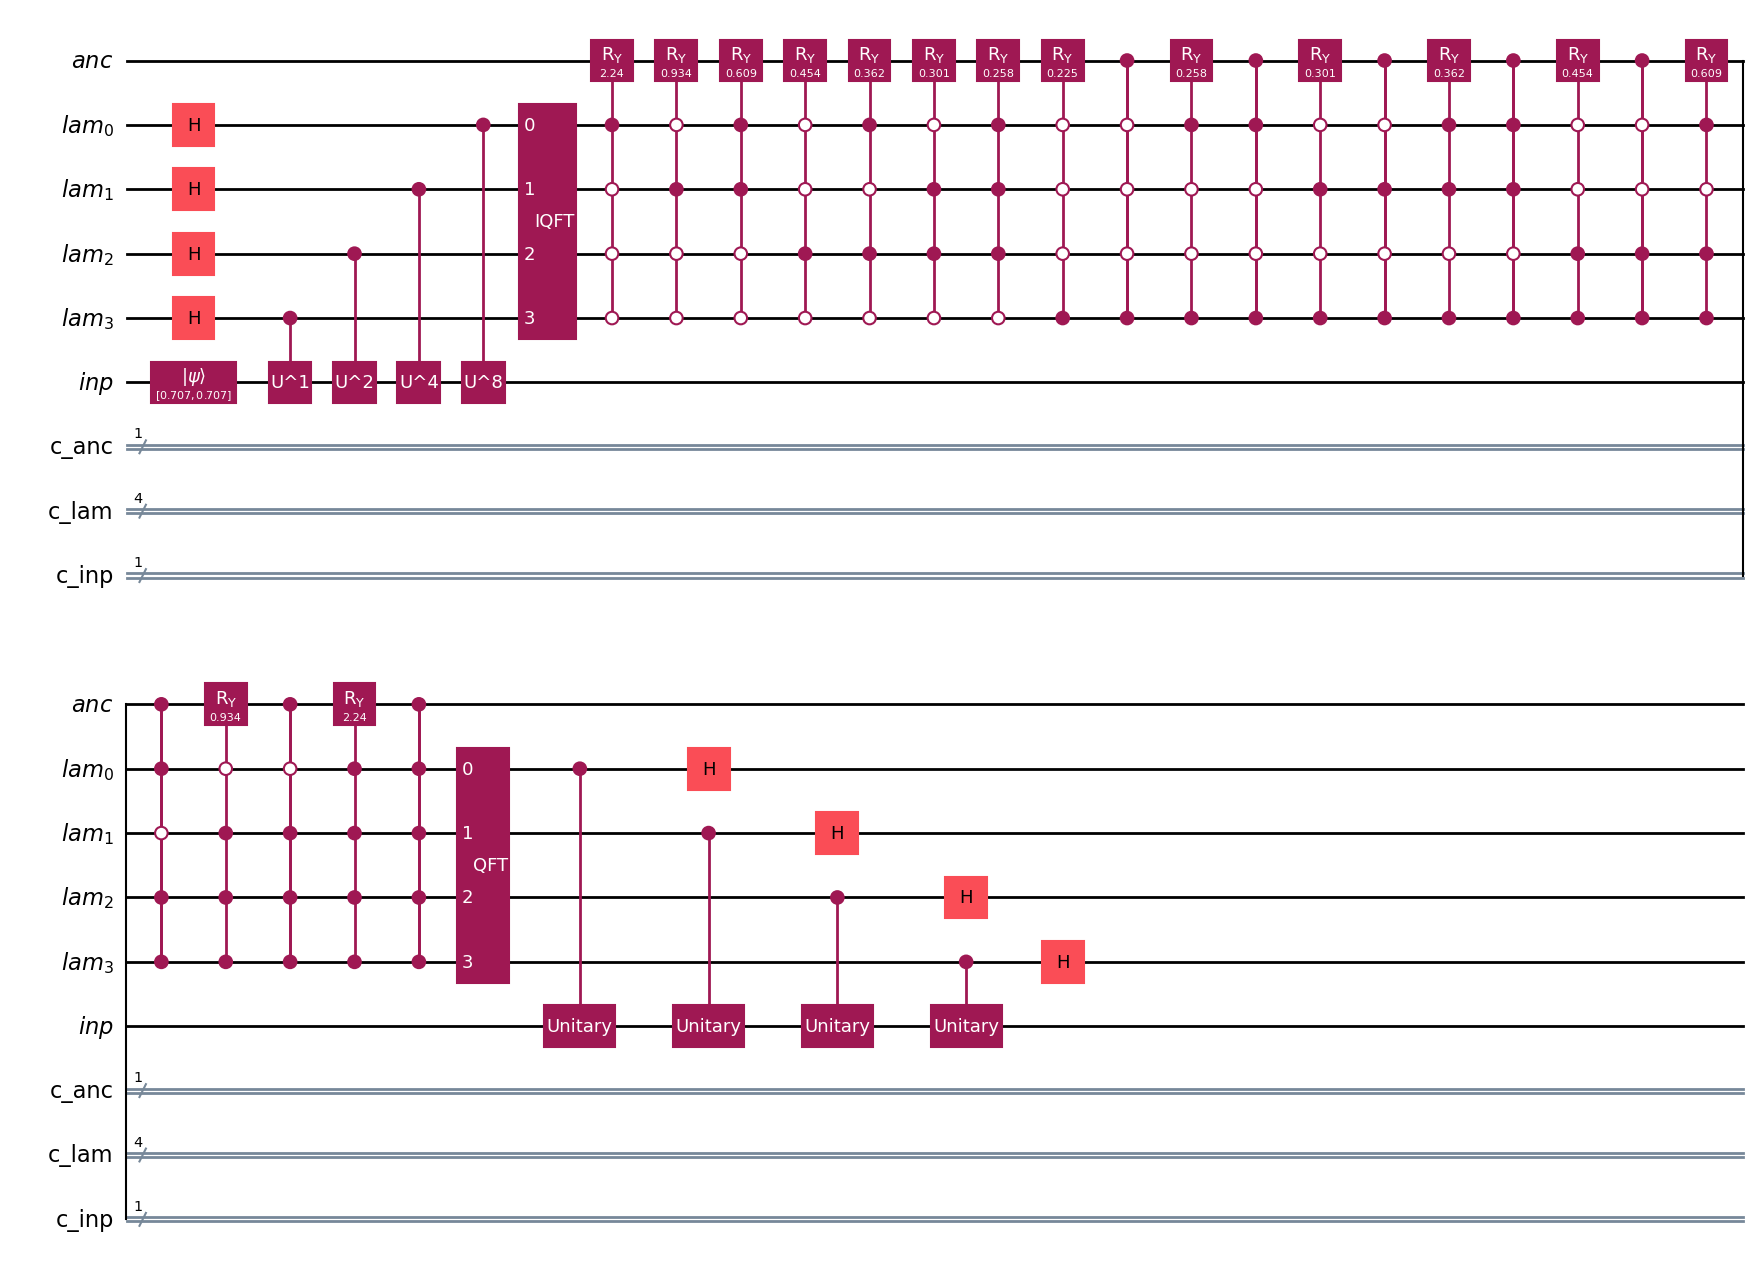


Expected state:


The lambda register should now uncompute to:

|0000>

while the ancilla remains entangled with
the input register.

Expected state:

(1/sqrt(2))

|0>|0000>
(
sqrt(1-(C/3)^2)|0>
+
(C/3)|1>
)

+

(1/sqrt(2))

|1>|0000>
(
sqrt(1-(C/0.5)^2)|0>
+
(C/0.5)|1>
)

For:

C = 0.45000

the expected amplitudes are:

|0>|0000>|0> : 0.69911

|0>|0000>|1> : 0.10607

|1>|0000>|0> : 0.30822

|1>|0000>|1> : 0.63640

(up to an overall global phase)


Wavefunction:

0.03083-0.69843j |0>|0000>|0> 
0.00468-0.10596j |0>|0000>|1> 
0.01359-0.30792j |1>|0000>|0> 
0.02806-0.63578j |1>|0000>|1> 


Displayed ordering:
| inp_(n-1)...inp_0 | lam_(m-1)...lam_0 | anc |

Amplitude Verification

Expected vs Observed:

|0>|0000>|0>
Expected modulus : 0.69911
Observed amplitude : -0.69911-0.00000j
Observed modulus : 0.69911

|0>|0000>|1>
Expected modulus : 0.10607
Observed amplitude : -0.10607+0.00000j
Observed modulus : 0.10607

|1>|0000>|0>
Expected modulus : 0.30822
Observed amplitude : -0.30822-0.000

In [12]:
# ============================================================
# Cell 8 : Apply QPE†
# ============================================================

print("\n================================================")
print("Applying QPE†")
print("================================================")

qpe_dagger(
    qc,
    lam,
    inp,
    U_gate,
    m
)

# ------------------------------------------------------------
# Visualize circuit
# ------------------------------------------------------------

display(
    qc.draw('mpl')
)

# ------------------------------------------------------------
# Expected state
# ------------------------------------------------------------

print("\nExpected state:\n")

print(
f"""
The lambda register should now uncompute to:

|0000>

while the ancilla remains entangled with
the input register.

Expected state:

(1/sqrt(2))

|0>|0000>
(
sqrt(1-(C/3)^2)|0>
+
(C/3)|1>
)

+

(1/sqrt(2))

|1>|0000>
(
sqrt(1-(C/0.5)^2)|0>
+
(C/0.5)|1>
)

For:

C = {C:.5f}

the expected amplitudes are:

|0>|0000>|0> : {0.707106*np.sqrt(1-(C/3)**2):.5f}

|0>|0000>|1> : {0.707106*(C/3):.5f}

|1>|0000>|0> : {0.707106*np.sqrt(1-(C/0.5)**2):.5f}

|1>|0000>|1> : {0.707106*(C/0.5):.5f}

(up to an overall global phase)
"""
)

# ------------------------------------------------------------
# Final wavefunction
# ------------------------------------------------------------

print("\nWavefunction:\n")

qc_transpiled = transpile(
    qc,
    state_sim
)

oq.Wavefunction(
    qc_transpiled,
    systems=[n,m,1],
    show_systems=[True,True,True],
    precision=5,
    column=True
)

print("\nDisplayed ordering:")
print("| inp_(n-1)...inp_0 | lam_(m-1)...lam_0 | anc |")

# ------------------------------------------------------------
# Compare expected and observed amplitudes
# ------------------------------------------------------------

print("\n================================================")
print("Amplitude Verification")
print("================================================")

statevec = Statevector(qc_transpiled)

expected = {

    "|0>|0000>|0>" :
        0.707106*np.sqrt(
            1-(C/3)**2
        ),

    "|0>|0000>|1>" :
        0.707106*(C/3),

    "|1>|0000>|0>" :
        0.707106*np.sqrt(
            1-(C/0.5)**2
        ),

    "|1>|0000>|1>" :
        0.707106*(C/0.5)
}

observed = {}

for i, amp in enumerate(statevec):

    if abs(amp) > 1e-10:

        bitstring = format(
            i,
            f'0{qc.num_qubits}b'
        )

        inp_bits = bitstring[0:n]
        lam_bits = bitstring[n:n+m]
        anc_bits = bitstring[-1]

        label = (
            f"|{inp_bits}>"
            f"|{lam_bits}>"
            f"|{anc_bits}>"
        )

        observed[label] = amp


print("\nExpected vs Observed:\n")

for key in expected:

    exp_amp = expected[key]

    obs_amp = observed[key]

    obs_mag = abs(obs_amp)

    print(
        f"{key}"
    )

    print(
        f"Expected modulus : "
        f"{exp_amp:.5f}"
    )

    print(
        f"Observed amplitude : "
        f"{obs_amp.real:.5f}"
        f"{obs_amp.imag:+.5f}j"
    )

    print(
        f"Observed modulus : "
        f"{obs_mag:.5f}"
    )

    print()

print("================================================")

In [13]:
# ============================================================
# Cell 9 : Postselect ancilla = |1>
# ============================================================

print("\n================================================")
print("Postselect ancilla = |1>")
print("================================================")

# ------------------------------------------------------------
# Obtain statevector
# ------------------------------------------------------------

qc_transpiled = transpile(
    qc,
    state_sim
)

statevec = Statevector(
    qc_transpiled
)

# ------------------------------------------------------------
# Project onto anc=1
#
# Qiskit ordering:
#
# |inp>|lam>|anc|
#
# anc is therefore last bit
# ------------------------------------------------------------

projected = np.zeros(
    len(statevec),
    dtype=complex
)

for i, amp in enumerate(statevec):

    bitstring = format(
        i,
        f'0{qc.num_qubits}b'
    )

    anc_bit = bitstring[-1]

    if anc_bit == '1':

        projected[i] = amp

# ------------------------------------------------------------
# Normalize
# ------------------------------------------------------------

success_probability = np.sum(
    np.abs(projected)**2
)

projected /= np.sqrt(
    success_probability
)

print(
    "\nSuccess probability:"
)

print(
    f"{success_probability:.6f}"
)

print(
    "\nPostselected wavefunction:\n"
)

oq.Wavefunction(
    projected,
    systems=[n,m,1],
    show_systems=[True,True,True],
    precision=5,
    column=True
)

print("\nDisplayed ordering:")
print("| inp_(n-1)...inp_0 | lam_(m-1)...lam_0 | anc |")

# ------------------------------------------------------------
# Expected HHL solution
# ------------------------------------------------------------

print("\nExpected HHL solution:\n")

# A^{-1}|b>

expected = np.array(

    [
        (1/3)/np.sqrt(2),
        2/np.sqrt(2)
    ],

    dtype=complex
)

expected /= np.linalg.norm(
    expected
)

print(
    "Normalized A^{-1}|b>:"
)

print(
    f"{expected[0]:.5f}|0> "
    f"+ "
    f"{expected[1]:.5f}|1>"
)

# ------------------------------------------------------------
# Extract observed input amplitudes
# ------------------------------------------------------------

print("\nObserved input amplitudes:\n")

input_amp = np.zeros(
    N,
    dtype=complex
)

for i, amp in enumerate(projected):

    if abs(amp) > 1e-10:

        bitstring = format(
            i,
            f'0{qc.num_qubits}b'
        )

        inp_bits = bitstring[0:n]
        lam_bits = bitstring[n:n+m]
        anc_bit = bitstring[-1]

        # Keep only lam=0000 and anc=1

        if (
            lam_bits=="0"*m
            and
            anc_bit=="1"
        ):

            index = int(
                inp_bits,
                2
            )

            input_amp[index] = amp

input_amp /= np.linalg.norm(
    input_amp
)

for i in range(N):

    print(
        f"{input_amp[i]:.5f}"
        f" |{i}>"
    )

print("\n================================================")


Postselect ancilla = |1>

Success probability:
0.416250

Postselected wavefunction:

-0.1644 |0>|0000>|1> 
-0.98639 |1>|0000>|1> 


Displayed ordering:
| inp_(n-1)...inp_0 | lam_(m-1)...lam_0 | anc |

Expected HHL solution:

Normalized A^{-1}|b>:
0.16440+0.00000j|0> + 0.98639+0.00000j|1>

Observed input amplitudes:

-0.16440+0.00000j |0>
-0.98639-0.00000j |1>

